# Prior

This notebook shows how the Gaussian prior shapes the embedding in IXPLORE.

- `apply_prior(prior_variance)` re-evaluates posteriors and embeddings under a new prior without recomputing the cached log-likelihoods.
- Sweep `prior_variance` and compare the resulting embeddings.
- Compare the posterior of a single user across prior settings.

In [1]:
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ixplore import IXPLORE
from ixplore.metrics import compute_rmse, compute_distortion
from ixplore.visualization import plot_embedding, clean_axis, colormap

logging.getLogger('ixplore').setLevel(logging.WARNING)

prior_grid = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]

## Load a pretrained model

Reuse the embedding and item parameters from `demo.ipynb` so the only thing that changes across this notebook is the prior.

In [2]:
users = pd.read_csv('../data/synthetic_users.csv', index_col=0)
reactions = pd.read_csv('../data/likert_reactions.csv', index_col=0)
embedding = pd.read_csv('../data/pretrained_embedding_likert.csv', index_col=0)
models = pd.read_csv('../data/pretrained_models_likert.csv', index_col=0)

model = IXPLORE(reactions,
                pretrained_embedding=embedding,
                pretrained_models=models)
model.fit_posteriors()

## Sweep `prior_variance`

After `fit_posteriors`, the per-user log-likelihoods are cached. `apply_prior(sigma)` only recomputes the prior and re-derives the embedding from the cache.

In [3]:
embeddings = {}
for sigma in prior_grid:
    model.apply_prior(sigma)
    embeddings[sigma] = model.get_embedding().copy()

## Embedding under different priors

Same users, same cached likelihoods, only `prior_variance` differs.

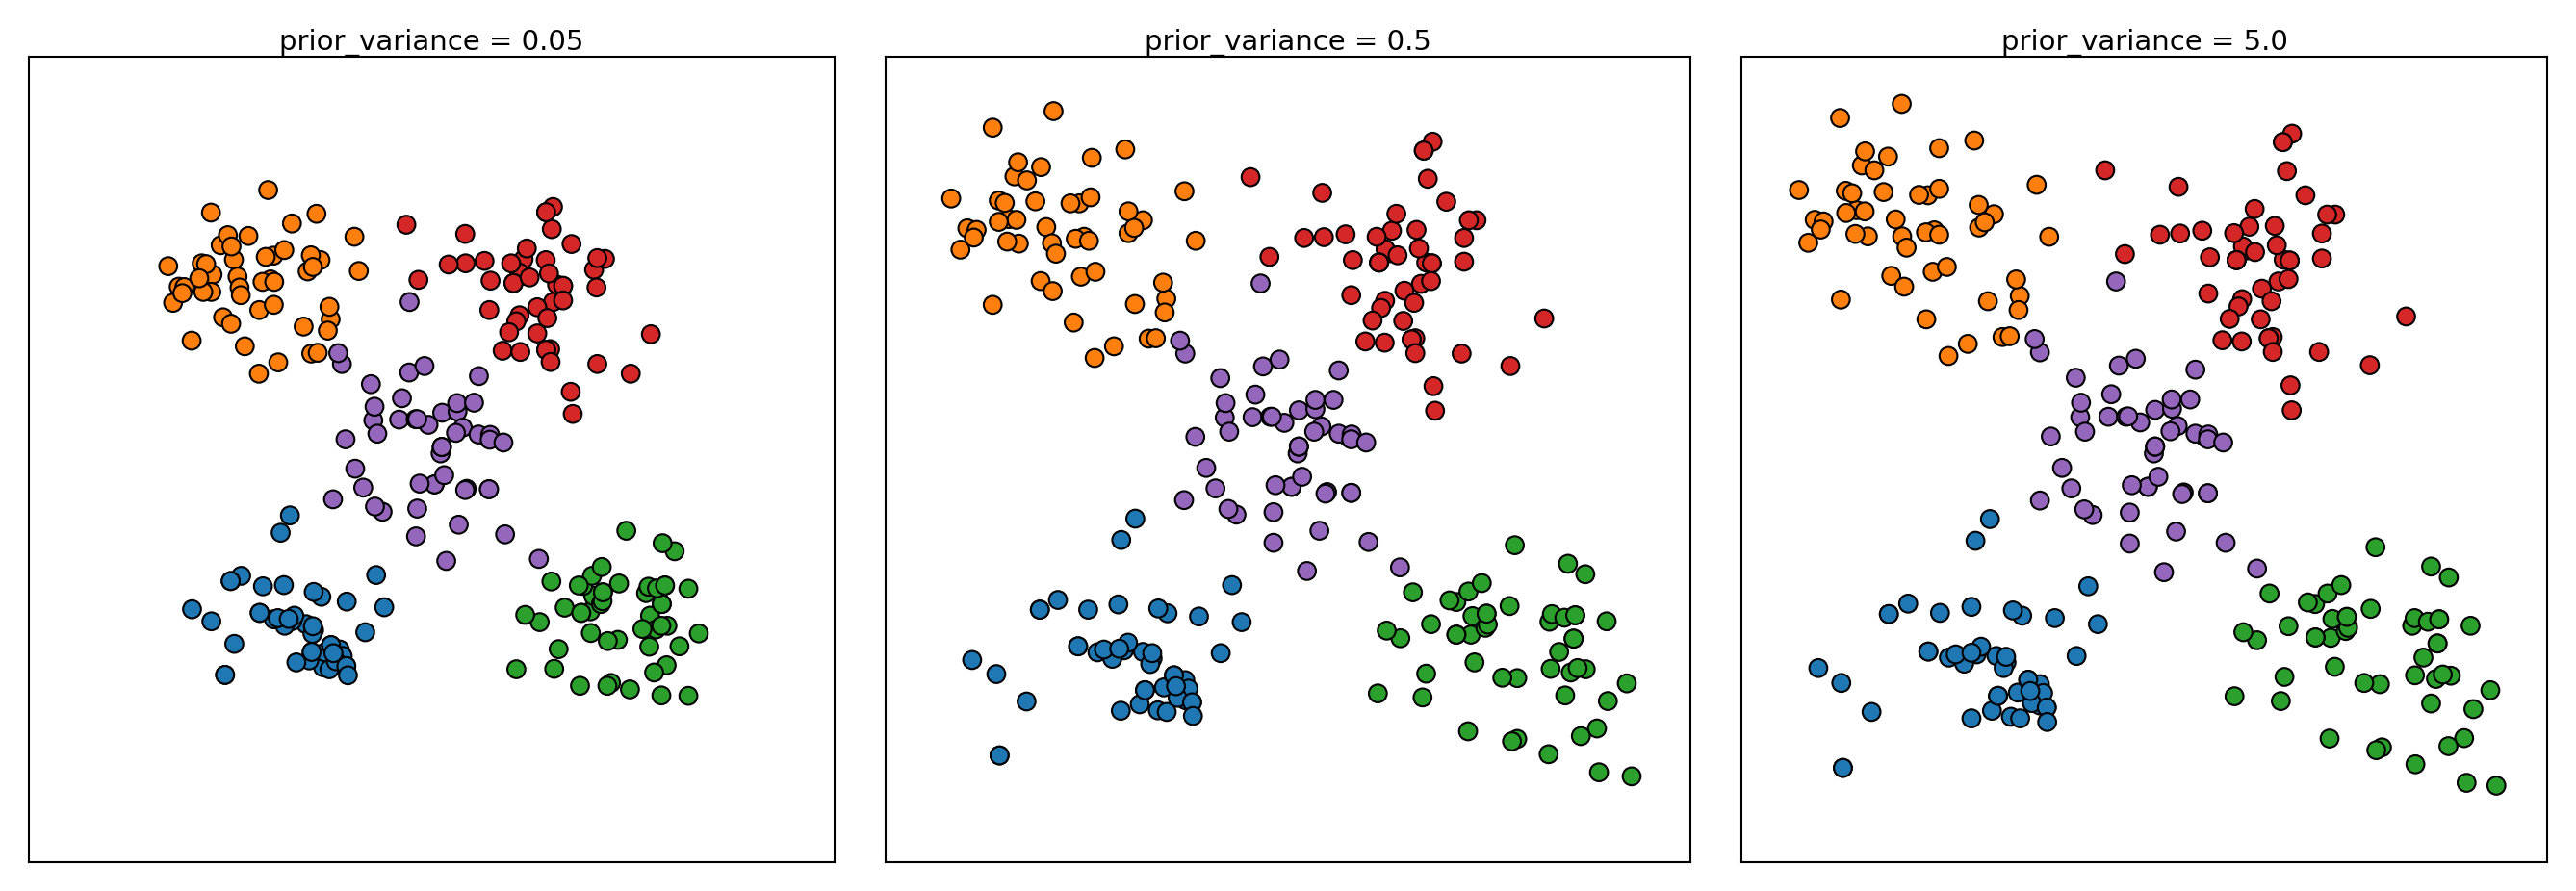

In [4]:
shown_priors = [prior_grid[0], prior_grid[3], prior_grid[-1]]

fig, axes = plt.subplots(1, len(shown_priors), figsize=(3 * len(shown_priors), 3),
                         sharex=True, sharey=True)
for ax, sigma in zip(axes, shown_priors):
    plot_embedding(embeddings[sigma], colors=users.color, s=20, ax=ax)
    clean_axis(ax)
    ax.set_title(f'prior_variance = {sigma}')
fig.tight_layout()
plt.show()

## Metrics across iterations

For each `prior_variance`, train a fresh model from scratch and record `evaluate()` after every iteration.

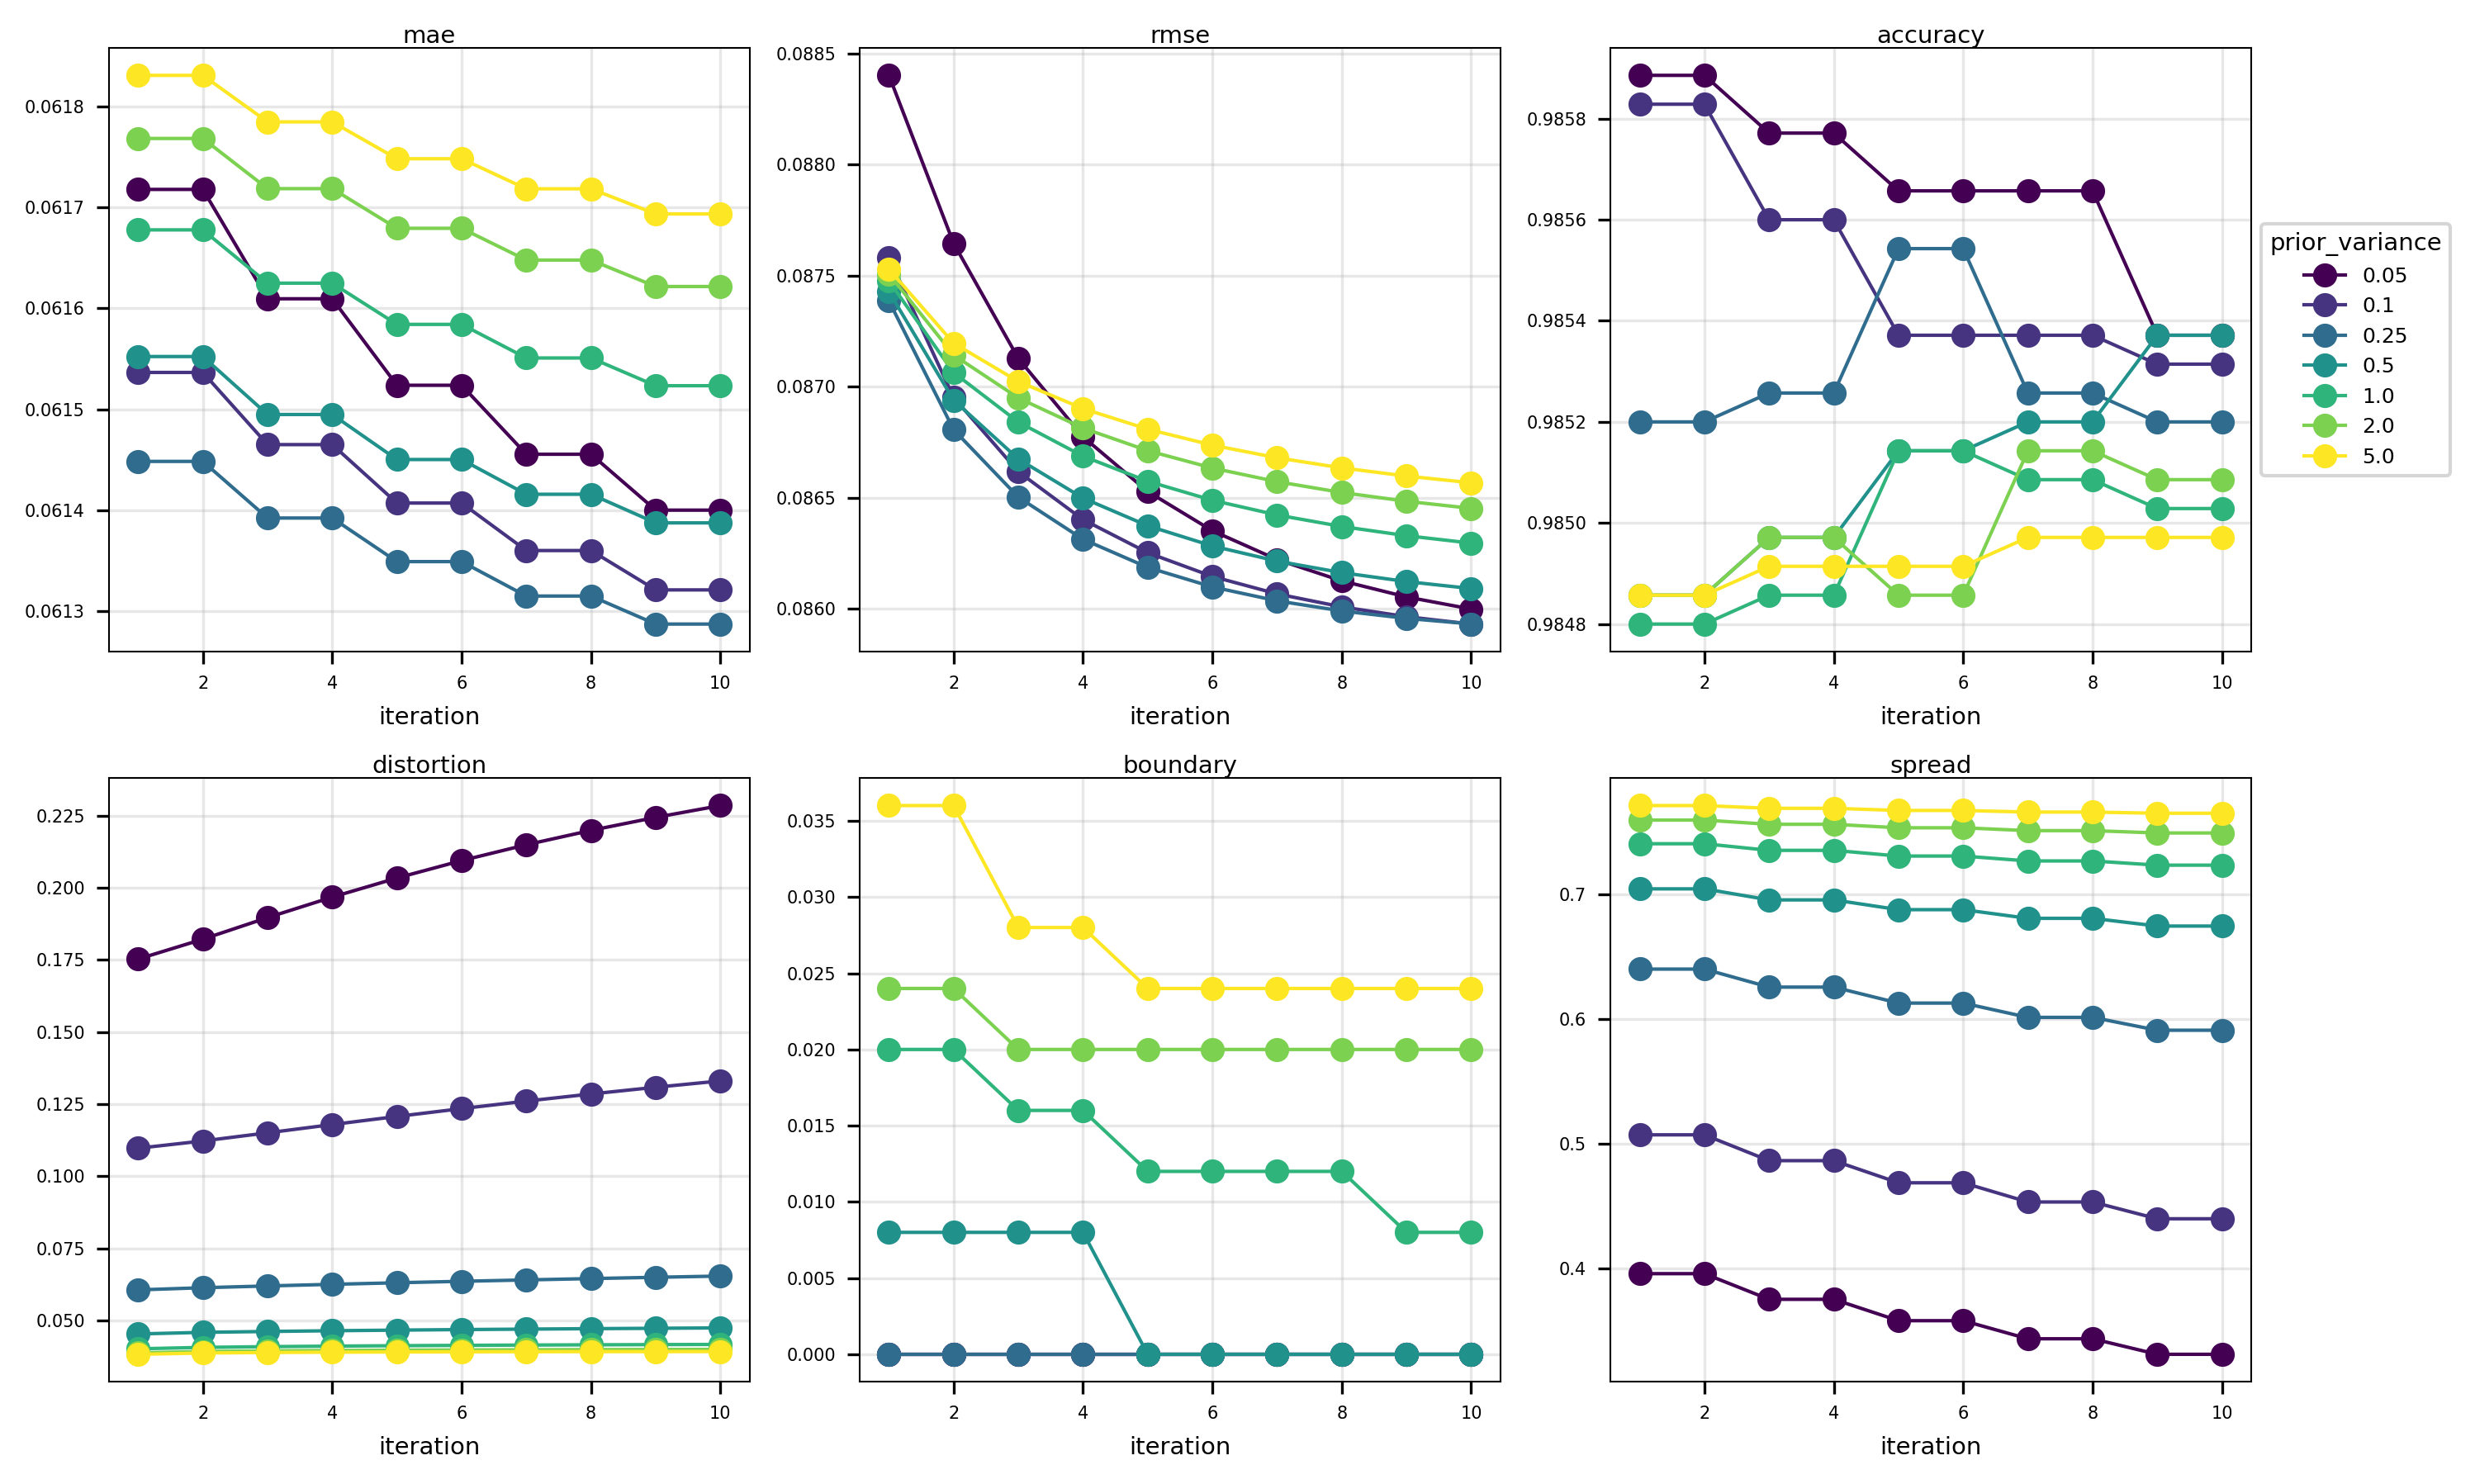

In [5]:
n_iterations = 10
metric_names = ['mae', 'rmse', 'accuracy', 'distortion', 'boundary', 'spread']

trajectories = {sigma: {m: [] for m in metric_names} for sigma in prior_grid}

for sigma in prior_grid:
    m = IXPLORE(reactions, prior_variance=sigma, pca_initialization=True, random_state=17)
    for _ in range(n_iterations):
        m.iterate(1)
        observed = ~np.isnan(m.reactions)
        preds = m.predict(m.embedding)
        rmse = compute_rmse(m.reactions[observed], preds[observed])
        distortion = compute_distortion(m)[2]
        trajectories[sigma]['rmse'].append(rmse)
        trajectories[sigma]['distortion'].append(distortion)
    for k in ('mae', 'accuracy', 'boundary', 'spread'):
        trajectories[sigma][k] = list(getattr(m.fit_logger, k))[-n_iterations:]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
cmap = plt.get_cmap('viridis')
norm_vals = np.log(prior_grid)
norm_vals = (norm_vals - norm_vals.min()) / (norm_vals.max() - norm_vals.min())

for ax, metric in zip(axes.ravel(), metric_names):
    for sigma, t in zip(prior_grid, norm_vals):
        ax.plot(range(1, n_iterations + 1), trajectories[sigma][metric],
                marker='o', color=cmap(t), label=f'{sigma}')
    ax.set_xlabel('iteration')
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
axes[0, -1].legend(title='prior_variance', fontsize=6, loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()
plt.show()

## Posterior of a sparse user

Take a single user, keep only their first 5 answers, and plot the posterior heatmap under each prior. Overlay the trajectory of point estimates as the answers are revealed one by one; the marker shows the current position after all 5 answers.

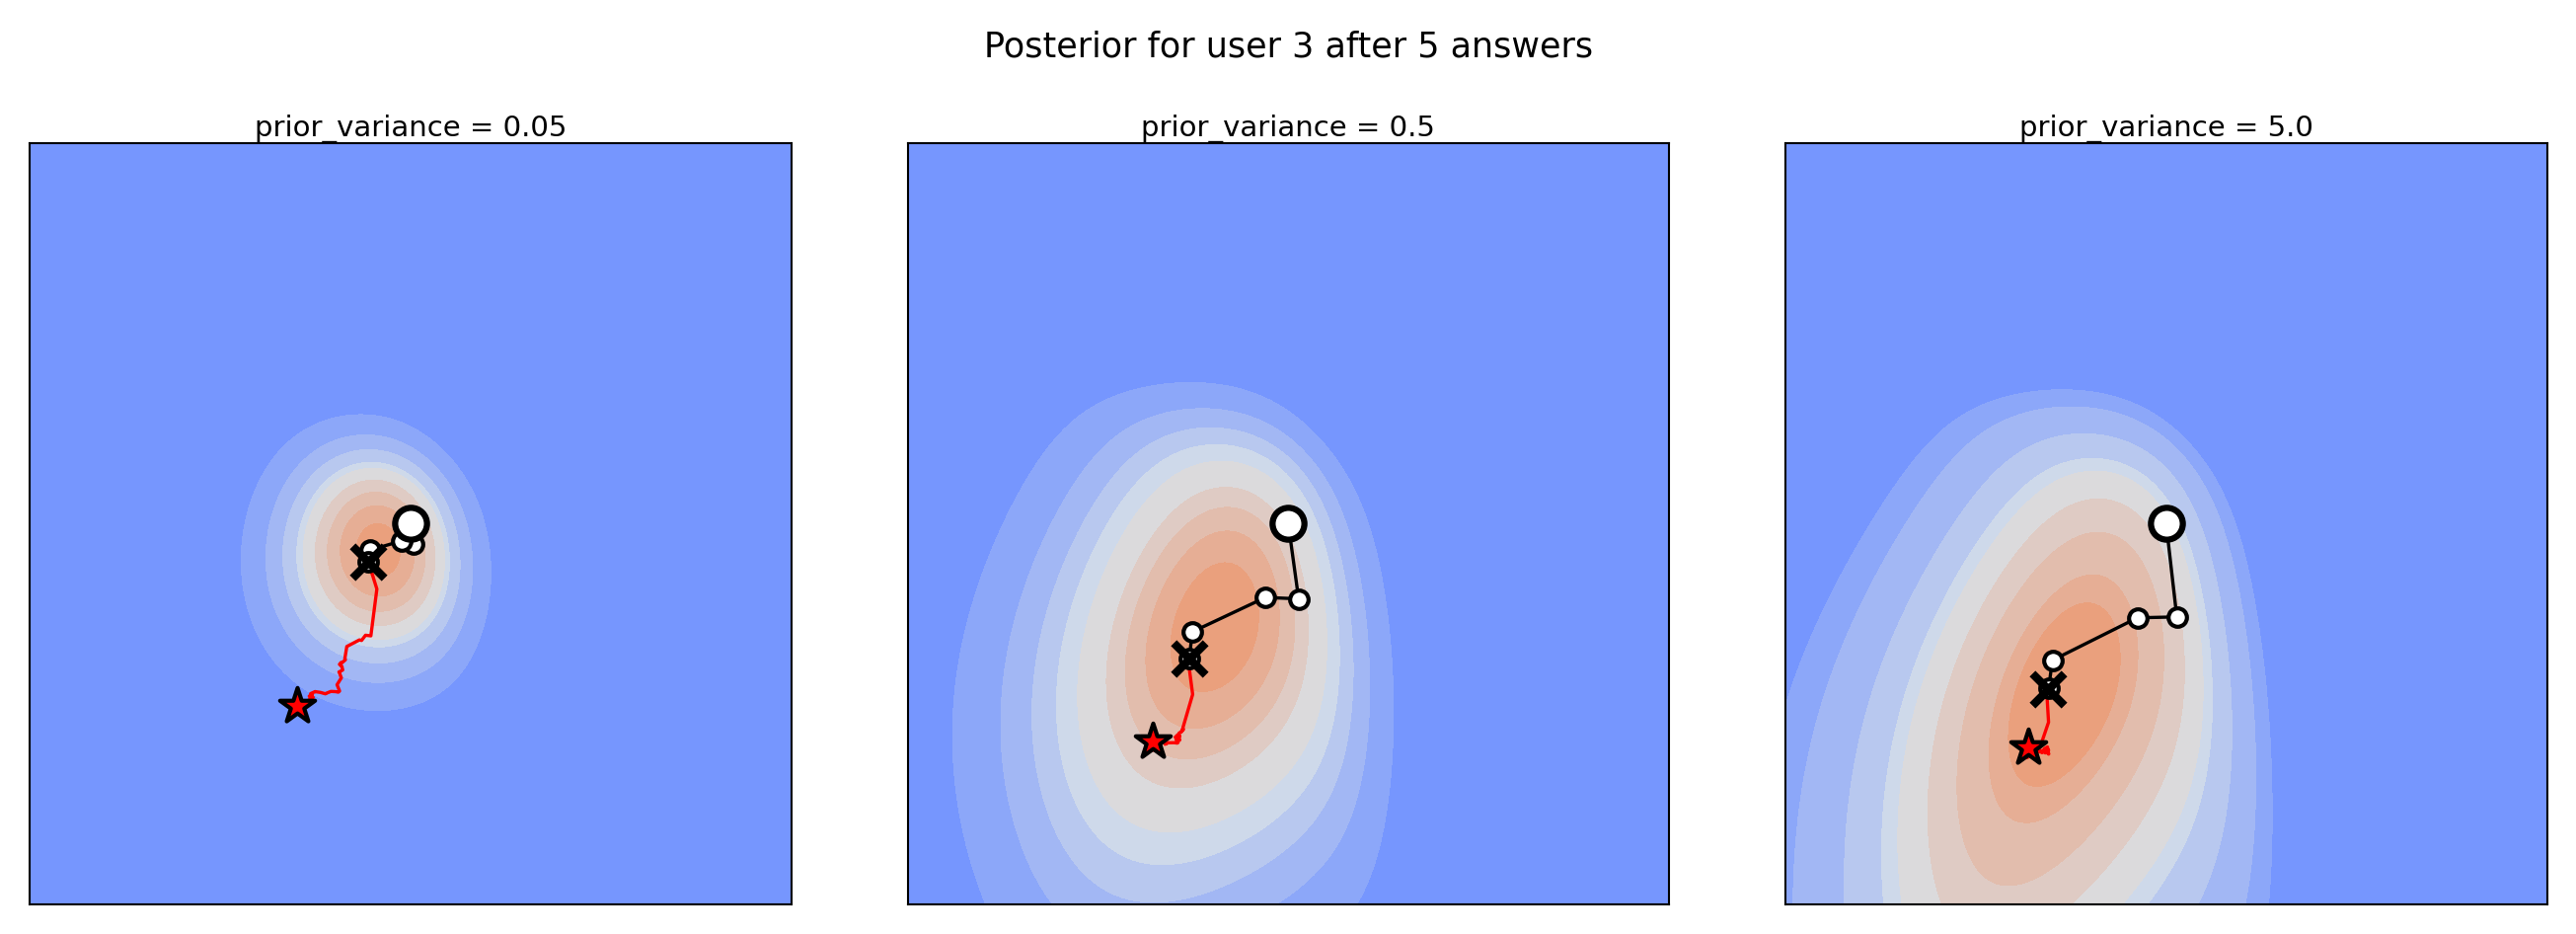

In [6]:
user_id = str(reactions.index[3])
n_answers = 5
user_idx = model.users.get_loc(user_id)
scaled_row = model.reactions[user_idx]
items = model.items
n_items = len(items)

def sparse_answers(k):
    a = pd.Series(np.nan, index=items, dtype=float, name=user_id)
    a.iloc[:k] = scaled_row[:k]
    return a

shown_priors = [prior_grid[0], prior_grid[3], prior_grid[-1]]
res = model.sampling_resolution
xx = model.X[:, 0].reshape(res, res)
yy = model.X[:, 1].reshape(res, res)

fig, axes = plt.subplots(1, len(shown_priors), figsize=(3 * len(shown_priors), 3),
                         sharex=True, sharey=True)
for ax, sigma in zip(axes, shown_priors):
    model.apply_prior(sigma)
    post = model.compute_posteriors(sparse_answers(n_answers))
    ax.contourf(xx, yy, post.reshape(res, res), levels=20, cmap=colormap)

    trajectory = np.array([model.embed(sparse_answers(k)) for k in range(0, n_items + 1)])
    early = trajectory[:n_answers + 1]
    late = trajectory[n_answers:]

    ax.plot(early[:, 0], early[:, 1], '-', color='black', lw=0.8, zorder=4)
    ax.scatter(early[1:-1, 0], early[1:-1, 1], color='white', edgecolors='black', s=20, zorder=5)
    ax.plot(late[:, 0], late[:, 1], '-', color='red', lw=0.8, zorder=4)

    ax.scatter(early[0, 0], early[0, 1], marker='o', color='white', edgecolors='black', s=60, lw=1.5, zorder=6)
    ax.scatter(early[-1, 0], early[-1, 1], marker='x', color='black', s=60, lw=2, zorder=6)
    ax.scatter(late[-1, 0], late[-1, 1], marker='*', color='red', edgecolors='black', s=80, zorder=6)

    clean_axis(ax)
    ax.set_title(f'prior_variance = {sigma}')
fig.suptitle(f'Posterior for user {user_id} after {n_answers} answers', y=1.02)
fig.tight_layout()
plt.show()

model.apply_prior(1.0)